# MVP — Machine Learning & Analytics

**Nome:** Tony Ribeiro Sá  
**Matrícula:** 4052025001862  
**Data:** 06/06/2026  
**Dataset:** Telco Customer Churn  
**Fonte dos dados:** Repositório GitHub público  
**Link do dataset:**  
https://raw.githubusercontent.com/Tony-maxrs/PROJETO-MVP-III---PUCRJ/main/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv

**Tipo de problema:** Classificação

---

## Objetivo do Projeto

Este MVP tem como objetivo desenvolver e avaliar modelos de Machine Learning capazes de prever a probabilidade de cancelamento (churn) de clientes de uma empresa de telecomunicações. A identificação antecipada de clientes com maior risco de cancelamento pode auxiliar estratégias de retenção, reduzindo perdas financeiras e melhorando o relacionamento com os clientes.





In [70]:
import pandas as pd

url = "https://raw.githubusercontent.com/Tony-maxrs/PROJETO-MVP-III---PUCRJ/main/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Linhas e Colunas:", df.shape)

df.head()

Linhas e Colunas: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Checklist do MVP

Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☑ |
| Dataset descrito, com fonte, atributos e restrições | ☑ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☑ |
| Análise exploratória objetiva, conectada à modelagem | ☑ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☑ |
| Prevenção de vazamento de dados | ☑ |
| Tratamentos de dados justificados | ☑ |
| Pipeline ou sequência reprodutível de pré-processamento | ☑ |
| Modelo baseline definido | ☑ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☑ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☑ |
| Avaliação com métricas coerentes com o problema | ☑ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☑ |
| Código limpo, organizado e executável do início ao fim | ☑ |
| Conclusão conectada ao objetivo inicial | ☑ |




# 1. Definição do problema

## Contexto

A retenção de clientes é um dos principais desafios enfrentados por empresas de telecomunicações. A perda de clientes gera impacto direto na receita e pode indicar problemas relacionados à qualidade dos serviços, preços ou atendimento.

Neste projeto será utilizado o dataset Telco Customer Churn, que contém informações demográficas, características dos serviços contratados e histórico de faturamento dos clientes.



## 1.2 Objetivo do MVP

Desenvolver um modelo de classificação capaz de prever se um cliente irá cancelar ou não os serviços da empresa.

## 1.3 Tipo de problema

Classificação supervisionada binária.

## Variável-Alvo

A variável alvo é:

**Churn**

Onde:

- Yes = Cliente cancelou o serviço;
- No = Cliente permaneceu na empresa.

## Justificativa para o uso de Machine Learning

O comportamento de cancelamento dos clientes pode ser influenciado por diversos fatores simultaneamente, tornando difícil identificar padrões manualmente.

Modelos de Machine Learning permitem aprender esses padrões a partir dos dados históricos e realizar previsões para novos clientes.


## 1.4 Premissas, hipóteses e critérios de sucesso

## Premissas

Os dados históricos disponibilizados representam adequadamente o comportamento dos clientes da empresa.
As informações cadastrais, contratuais e financeiras foram registradas corretamente.
A variável Churn reflete corretamente a situação de cancelamento dos clientes.

## Hipóteses

Clientes com contratos mensais possuem maior probabilidade de cancelamento.
Clientes com menor tempo de permanência tendem a cancelar com mais frequência.
O valor mensal pago pelo cliente pode influenciar a decisão de cancelamento.
Serviços adicionais contratados podem contribuir para a retenção dos clientes.

## Critérios de Sucesso

O MVP será considerado bem-sucedido caso os modelos de Machine Learning consigam identificar padrões relevantes associados ao cancelamento de clientes e apresentem desempenho superior ao modelo baseline, utilizando principalmente a métrica F1-Score, complementada por Accuracy, Precision, Recall e ROC-AUC.


# 2. Ambiente, bibliotecas e reprodutibilidade

Este projeto foi desenvolvido utilizando Python e bibliotecas amplamente empregadas em projetos de Ciência de Dados e Machine Learning.

As principais bibliotecas utilizadas incluem:

#### Pandas: manipulação e análise de dados;
#### NumPy: operações numéricas;
#### Matplotlib e Seaborn: visualização de dados;
#### Scikit-Learn: pré-processamento, modelagem e avaliação dos modelos de Machine Learning.

Para garantir a reprodutibilidade dos resultados, foi definida uma semente aleatória (random seed), permitindo que os experimentos produzam resultados consistentes em diferentes execuções.


In [71]:
# Bibliotecas principais

import pandas as pd
import numpy as np

# Visualização

import matplotlib.pyplot as plt
import seaborn as sns
import time

# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from scipy.stats import randint

# Reprodutibilidade

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Ambiente configurado com sucesso!")

Ambiente configurado com sucesso!


## 2.1 Dependências adicionais

Para este projeto, não foi necessária a instalação de dependências adicionais além das bibliotecas padrão já importadas no notebook, como `pandas`, `numpy`, `matplotlib`, `seaborn` e módulos do `scikit-learn`.

Todo o fluxo de preparação dos dados, treinamento, validação, otimização e avaliação foi executado utilizando apenas essas bibliotecas.



## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.




In [72]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste projeto é o Telco Customer Churn, amplamente empregado em estudos de Machine Learning voltados à retenção de clientes.

A base contém informações demográficas, características dos serviços contratados, tempo de relacionamento com a empresa e informações financeiras dos clientes.

O objetivo é prever a variável Churn, indicando se o cliente cancelou ou não os serviços da empresa.

Os dados foram disponibilizados através de um arquivo CSV armazenado em um repositório GitHub público, permitindo a reprodução completa do projeto


## 3.2 Carga dos dados

Carga Real dos Dados




In [73]:
# Carregamento dos dados

url = "https://raw.githubusercontent.com/Tony-maxrs/PROJETO-MVP-III---PUCRJ/main/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 7043
Quantidade de colunas: 21


## 3.3 Visão geral do dataset

Após o carregamento da base, será realizada uma inspeção inicial para compreender sua estrutura.

Serão avaliados:

Quantidade de registros;
Quantidade de atributos;
Tipos das variáveis;
Presença de valores ausentes;
Características gerais do conjunto de dados.

Essa etapa é fundamental para orientar as decisões de preparação e modelagem que serão realizadas posteriormente.


In [74]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Observações Iniciais

A inspeção inicial da base permitiu identificar que o dataset possui 7.043 registros distribuídos em 21 atributos.

Não foram identificados valores nulos diretamente através do método info(). Entretanto, observou-se que a variável TotalCharges foi carregada como tipo object, embora represente um valor numérico.

Esse comportamento sugere a existência de registros vazios ou inconsistentes que serão investigados e tratados durante a etapa de preparação dos dados.

In [76]:
df["TotalCharges"].head(10)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [77]:
df["TotalCharges"].dtype

dtype('O')

In [78]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

## Qualidade dos Dados

Foi identificada uma inconsistência na variável TotalCharges, que foi carregada como tipo object em vez de numérica.

Uma investigação adicional revelou a existência de 11 registros contendo valores em branco, o que impediu a conversão automática da coluna para um formato numérico.

Esse problema será tratado na etapa de preparação dos dados, onde os valores ausentes serão convertidos adequadamente para permitir sua utilização pelos algoritmos de Machine Learning.

In [79]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [80]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## Principais Variáveis

Algumas das variáveis mais relevantes presentes na base são:

1 - customerID: identificador único do cliente;

2 - gender: gênero do cliente;

3 - SeniorCitizen: indica se o cliente é idoso;

4 - tenure: tempo de permanência do cliente na empresa;

5 - Contract: tipo de contrato;

6 - MonthlyCharges: valor mensal cobrado;

7 - TotalCharges: valor total pago pelo cliente;

8 - InternetService: tipo de serviço de internet contratado;

9 - PaymentMethod: forma de pagamento utilizada;

10 - Churn: variável alvo que indica se o cliente cancelou ou não os serviços.

Essas variáveis serão analisadas em maior profundidade durante a etapa de análise exploratória dos dados.

## 3.4 Dicionário de dados

| Coluna          | Tipo       | Descrição                       | Será usada no modelo? | Observações                                   |
| --------------- | ---------- | ------------------------------- | --------------------- | --------------------------------------------- |
| customerID      | categórica | Identificador único do cliente  | Não                   | Removida por não possuir capacidade preditiva |
| tenure          | numérica   | Tempo de permanência do cliente | Sim                   | Variável importante para retenção             |
| MonthlyCharges  | numérica   | Valor mensal cobrado            | Sim                   | Relacionada ao comportamento financeiro       |
| TotalCharges    | numérica   | Valor total pago pelo cliente   | Sim                   | Necessitou tratamento de dados                |
| Contract        | categórica | Tipo de contrato                | Sim                   | Forte relação com churn                       |
| InternetService | categórica | Tipo de serviço de internet     | Sim                   | Possível fator de cancelamento                |
| PaymentMethod   | categórica | Forma de pagamento              | Sim                   | Pode influenciar retenção                     |
| Churn           | alvo       | Indica cancelamento do cliente  | Alvo                  | Variável a ser prevista                       |



# 4. Análise exploratória dos dados

Nesta etapa serão realizadas análises gráficas e estatísticas com o objetivo de compreender melhor o comportamento dos clientes e identificar possíveis padrões associados ao cancelamento dos serviços.

A análise exploratória também permite detectar problemas de qualidade dos dados e gerar hipóteses que poderão ser avaliadas pelos modelos de Machine Learning.


In [81]:
# Distribuição da variável alvo

df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


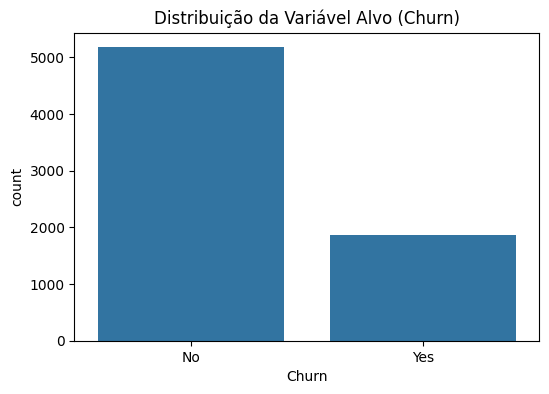

In [82]:
# Visualização da Distribuição da Variável Alvo (Churn)

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Distribuição da Variável Alvo (Churn)")
plt.show()

In [83]:
# Distribuição percentual

df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


## Análise da Variável Alvo

A variável alvo apresenta duas classes:

* Clientes que permaneceram na empresa (No): 5.174 registros (73,46%);
* Clientes que cancelaram os serviços (Yes): 1.869 registros (26,54%).

Observa-se um desbalanceamento moderado entre as classes, com predominância de clientes que permaneceram ativos.

Embora esse nível de desbalanceamento não seja severo, a utilização exclusiva da métrica Accuracy pode levar a interpretações equivocadas sobre o desempenho dos modelos. Por esse motivo, serão utilizadas métricas complementares como Precision, Recall, F1-Score e ROC-AUC durante a avaliação dos modelos.

Além disso, a taxa de cancelamento observada indica que aproximadamente um em cada quatro clientes deixou a empresa, reforçando a relevância do problema de negócio analisado neste estudo.


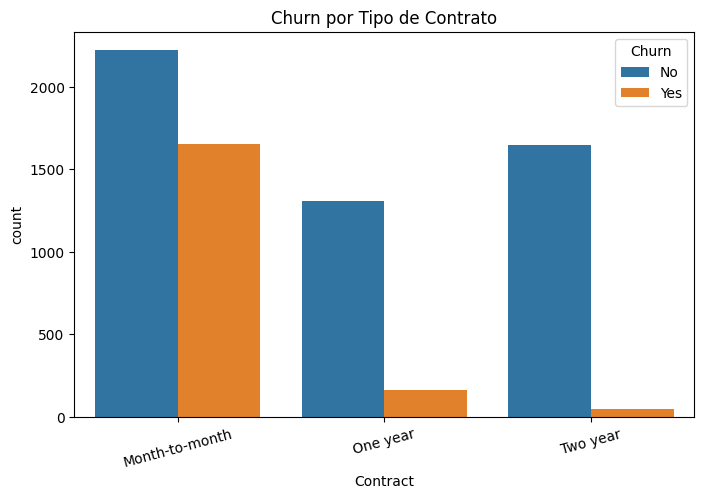

In [84]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn por Tipo de Contrato")
plt.xticks(rotation=15)
plt.show()

In [85]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


## Relação entre Tipo de Contrato e Cancelamento

A análise revelou uma forte relação entre o tipo de contrato e a ocorrência de cancelamento.

Clientes com contratos mensais (Month-to-month) apresentaram taxa de cancelamento de aproximadamente 42,7%, enquanto clientes com contratos anuais apresentaram taxa de apenas 11,3%. Entre os clientes com contratos de dois anos, a taxa de cancelamento foi inferior a 3%.

Esses resultados sugerem que contratos de maior duração contribuem significativamente para a retenção de clientes, reduzindo a probabilidade de cancelamento.

Esse comportamento está alinhado com uma das hipóteses definidas no início do projeto e indica que a variável Contract possui elevado potencial preditivo para os modelos de Machine Learning.

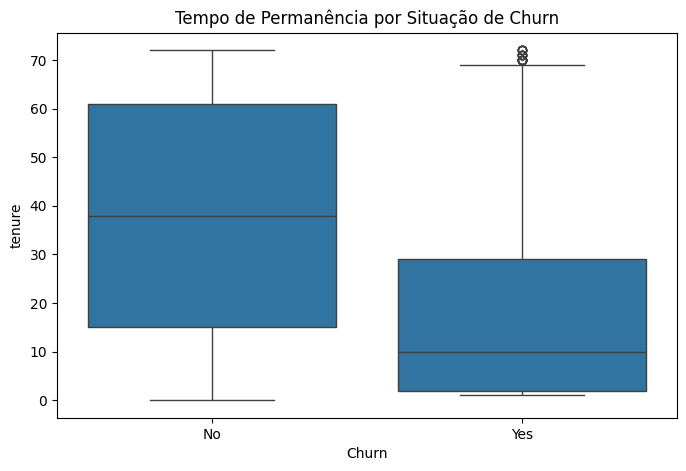

In [86]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tempo de Permanência por Situação de Churn")
plt.show()

In [87]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


## 4.1 Síntese da Análise Exploratória

A análise exploratória permitiu identificar padrões relevantes associados ao cancelamento dos clientes.

Os principais achados foram:

A variável alvo apresenta desbalanceamento moderado, com aproximadamente 73,5% dos clientes permanecendo na empresa e 26,5% cancelando os serviços.
Foi identificada uma inconsistência na variável TotalCharges, que foi carregada como texto devido à existência de 11 registros contendo valores em branco.
O tipo de contrato apresentou forte relação com o cancelamento. Clientes com contratos mensais possuem taxa de churn significativamente superior aos clientes com contratos anuais ou bianuais.
O tempo de permanência (tenure) também demonstrou elevada capacidade explicativa. Clientes que cancelaram apresentam, em média, menos da metade do tempo de relacionamento observado entre clientes que permaneceram ativos.

Esses resultados indicam que variáveis relacionadas ao vínculo contratual e ao histórico de relacionamento do cliente possuem forte potencial preditivo e deverão contribuir significativamente para o desempenho dos modelos de Machine Learning.


In [88]:
# Tratamento da variável TotalCharges

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].isna().sum())

11


In [89]:
# Remoção dos registros inconsistentes

df = df.dropna(subset=["TotalCharges"])

print(df.shape)

(7032, 21)


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa foram definidas as variáveis preditoras e a variável alvo do problema.

A coluna customerID foi tratada como identificador e removida do conjunto de atributos utilizados na modelagem.

Também foi identificado um problema de qualidade na variável TotalCharges, que continha 11 registros vazios. Esses registros foram convertidos para valores ausentes e removidos da base antes da modelagem.

Por fim, os dados foram divididos em conjuntos de treino e teste, permitindo avaliar o desempenho dos modelos em observações não utilizadas durante o treinamento.


In [90]:
# === Configuração do problema ===

TARGET = "Churn"

PROBLEM_TYPE = "classificacao"

ID_COLUMNS = ["customerID"]

DATE_COLUMN = None

DROP_COLUMNS = []

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)

if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

Tipo de problema: classificacao
Target: Churn
Número de features: 19
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [91]:
# === Divisão dos dados ===

SEED = 42

if PROBLEM_TYPE in ["classificacao", "regressao"]:

    X = df[features].copy()
    y = df[TARGET].copy()

    stratify = y if PROBLEM_TYPE == "classificacao" else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=SEED,
        stratify=stratify
    )

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test:", y_test.shape)

X_train: (5625, 19)
X_test: (1407, 19)
y_train: (5625,)
y_test: (1407,)


## 5.1 Justificativa da divisão

Foi utilizada a estratégia Holdout, com divisão de 80% dos dados para treinamento e 20% para teste.

A proporção escolhida é adequada para o tamanho do dataset, permitindo que o modelo seja treinado com uma quantidade significativa de observações e, ao mesmo tempo, avaliado em dados não utilizados durante o treinamento.

Como o problema é de classificação e existe desbalanceamento entre as classes, foi utilizada estratificação (stratify=y) para preservar a proporção original de clientes que cancelaram e que permaneceram na empresa em ambos os conjuntos.

A remoção da variável customerID evita vazamento de informação e impede que o modelo utilize identificadores sem valor preditivo.

# 6. Pré-processamento e pipeline

Nesta etapa foi construída uma sequência reprodutível de pré-processamento dos dados, com o objetivo de preparar as variáveis para o treinamento dos modelos de Machine Learning de forma consistente e sem vazamento de informação entre treino e teste.

Como o dataset contém variáveis numéricas e categóricas, foi adotado um pipeline com tratamento separado para cada tipo de atributo. Para as variáveis numéricas, foram aplicadas imputação de valores ausentes pela mediana e padronização por meio do `StandardScaler`. Para as variáveis categóricas, foi utilizada imputação pela categoria mais frequente e codificação via `OneHotEncoder`, permitindo transformar categorias textuais em representações numéricas compatíveis com os algoritmos.

A utilização de `Pipeline` e `ColumnTransformer` garante que todas as transformações sejam aplicadas de forma padronizada tanto no conjunto de treino quanto no conjunto de teste, preservando a reprodutibilidade do processo e reduzindo o risco de inconsistências na preparação dos dados.




In [92]:
# Identificação automática simples de colunas numéricas e categóricas.
# Revise manualmente, especialmente se houver datas, IDs, texto livre ou categorias codificadas como números.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Colunas categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6.1 Decisões de pré-processamento


Para garantir a compatibilidade dos dados com os algoritmos de Machine Learning, foi implementado um pipeline de pré-processamento utilizando recursos do Scikit-Learn.

As variáveis numéricas foram tratadas por meio de imputação utilizando a mediana, estratégia escolhida por sua robustez em relação a possíveis valores extremos. Em seguida, foi aplicada padronização através do StandardScaler, permitindo que variáveis com diferentes escalas contribuam de forma equilibrada para o treinamento dos modelos.

As variáveis categóricas foram transformadas utilizando One-Hot Encoding, convertendo categorias textuais em representações numéricas adequadas para utilização pelos algoritmos.

A coluna `customerID` foi removida do conjunto de atributos por representar apenas um identificador único dos clientes, sem capacidade preditiva para o problema estudado.

Adicionalmente, a variável `TotalCharges` foi convertida para formato numérico e os registros inconsistentes identificados durante a análise exploratória foram removidos antes da etapa de modelagem.

Todo o fluxo de transformação foi encapsulado em um Pipeline, garantindo reprodutibilidade, evitando vazamento de dados (data leakage) e permitindo que os mesmos tratamentos sejam aplicados de forma consistente tanto nos dados de treinamento quanto nos dados de teste.


# 7. Baseline e modelos candidatos

Após a etapa de preparação dos dados, foram definidos um modelo baseline e dois modelos candidatos para o problema de classificação de churn.

Como baseline, foi utilizado um `DummyClassifier`, cuja função é estabelecer uma referência mínima de desempenho. Esse modelo não busca aprender padrões complexos dos dados, mas serve como ponto de comparação para verificar se os modelos de Machine Learning efetivamente agregam capacidade preditiva ao problema.

Em seguida, foram avaliados dois modelos supervisionados de classificação: **Regressão Logística** e **Random Forest**. A Regressão Logística foi escolhida por sua simplicidade, interpretabilidade e bom desempenho em problemas binários, enquanto o Random Forest foi incluído por sua capacidade de capturar relações não lineares e interações entre variáveis.

A comparação entre baseline e modelos candidatos foi realizada com base em métricas apropriadas para classificação, permitindo identificar quais abordagens apresentaram melhor equilíbrio entre capacidade preditiva, robustez e aplicabilidade ao problema de churn.





In [93]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos


Para este projeto foram selecionados dois algoritmos de classificação supervisionada amplamente utilizados em problemas de previsão de churn.

A Regressão Logística foi escolhida por ser um modelo simples, eficiente e de fácil interpretação, servindo como uma importante referência para problemas de classificação binária. Além disso, permite compreender como diferentes variáveis influenciam a probabilidade de cancelamento dos clientes.

O Random Forest foi selecionado por sua capacidade de capturar relações não lineares entre as variáveis e por apresentar excelente desempenho em bases tabulares contendo atributos numéricos e categóricos. O algoritmo também é robusto a ruídos e reduz o risco de overfitting quando comparado a árvores de decisão individuais.

A comparação entre esses dois modelos permitirá avaliar tanto uma abordagem mais interpretável quanto uma abordagem mais robusta e flexível, identificando qual delas apresenta melhor capacidade preditiva para o problema estudado.


# 8. Treinamento e avaliação inicial

Nesta etapa foram treinados o modelo baseline e os modelos candidatos definidos anteriormente, com o objetivo de comparar seus desempenhos iniciais no problema de classificação de churn.

O baseline foi utilizado como referência mínima de desempenho, permitindo verificar se os modelos supervisionados realmente capturam padrões relevantes nos dados. Em seguida, foram treinados os modelos de Regressão Logística e Random Forest, ambos integrados ao pipeline de pré-processamento definido nas etapas anteriores.

A comparação inicial foi realizada com base em métricas adequadas para classificação, como Accuracy, F1-Score ponderado e ROC-AUC, permitindo identificar o desempenho relativo de cada abordagem antes da etapa de otimização de hiperparâmetros.



In [94]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.734186,0.621651,0.500000,0.053
LogisticRegression,0.803838,0.799753,0.835929,0.089
RandomForest,0.787491,0.777800,0.813661,0.839


## 8.1 Análise dos resultados iniciais

Os resultados obtidos demonstram que ambos os modelos de Machine Learning superaram significativamente o modelo baseline.

O baseline apresentou Accuracy de aproximadamente 73,4% e ROC-AUC de 0,50, indicando ausência de capacidade discriminatória real entre clientes que cancelaram e clientes que permaneceram na empresa.

A Regressão Logística apresentou o melhor desempenho geral, alcançando Accuracy de 80,4%, F1-Score ponderado de 0,800 e ROC-AUC de 0,836. Esses resultados indicam elevada capacidade de identificação dos padrões associados ao cancelamento dos clientes.

O Random Forest também apresentou desempenho satisfatório, com Accuracy de 78,7%, F1-Score ponderado de 0,778 e ROC-AUC de 0,814. Embora tenha superado amplamente o baseline, seu desempenho foi inferior ao obtido pela Regressão Logística.

Com base nessa avaliação inicial, a Regressão Logística apresentou o melhor equilíbrio entre capacidade preditiva e desempenho geral, tornando-se uma forte candidata para as etapas seguintes de otimização e avaliação final.



# 9. Validação e otimização de hiperparâmetros

Nesta etapa foi realizada a otimização de hiperparâmetros do modelo **Random Forest**, com o objetivo de investigar possíveis ganhos de desempenho em relação à configuração padrão utilizada na avaliação inicial.

A estratégia adotada foi a **validação cruzada estratificada com 5 folds** (`StratifiedKFold`), preservando a proporção entre as classes da variável-alvo em cada partição. Como métrica principal de avaliação, foi utilizado o **F1-score ponderado**, por ser mais adequado a cenários com desbalanceamento entre classes e por considerar simultaneamente precisão e recall.

Os hiperparâmetros avaliados incluíram:
- número de árvores do modelo (`n_estimators`);
- profundidade máxima das árvores (`max_depth`);
- número mínimo de observações para divisão de um nó (`min_samples_split`).

A busca foi realizada por meio de **RandomizedSearchCV**, permitindo testar combinações distintas de hiperparâmetros com menor custo computacional do que uma busca exaustiva.



In [95]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.7957535976747856
Melhores hiperparâmetros: {'model__max_depth': 12, 'model__min_samples_split': 9, 'model__n_estimators': 166}


## 9.1 Discussão da otimização

Com o objetivo de melhorar o desempenho do modelo Random Forest, foi realizada uma busca sistemática de hiperparâmetros utilizando validação cruzada (Cross Validation).

Foram avaliadas diferentes combinações de parâmetros relacionados à complexidade das árvores e à quantidade de estimadores do modelo.

O processo identificou como melhor configuração:

* Número de árvores (`n_estimators`): 166
* Profundidade máxima (`max_depth`): 12
* Número mínimo de observações para divisão (`min_samples_split`): 9

A melhor combinação alcançou score médio de aproximadamente 0,796 durante a validação cruzada, indicando boa capacidade de generalização para dados não observados durante o treinamento.

A utilização de validação cruzada reduz o risco de overfitting e fornece uma estimativa mais confiável do desempenho esperado do modelo em novos dados.

Embora a Regressão Logística tenha apresentado o melhor desempenho na avaliação inicial, optou-se por realizar a etapa de otimização no modelo Random Forest por se tratar de um algoritmo mais sensível ao ajuste de hiperparâmetros, com maior potencial de ganho de desempenho após calibração. A Regressão Logística, por sua vez, já tende a apresentar comportamento mais estável com parametrização padrão. Assim, a otimização foi utilizada como forma de investigar se o Random Forest poderia alcançar desempenho competitivo após ajuste fino.



# 10. Avaliação final no conjunto de teste

Após a etapa de otimização de hiperparâmetros, o modelo Random Forest ajustado foi avaliado no conjunto de teste, composto por observações não utilizadas no treinamento nem na seleção dos hiperparâmetros.

Essa etapa tem como objetivo verificar o desempenho final do modelo em dados não vistos, permitindo comparar os resultados com o baseline e com os modelos avaliados anteriormente, além de analisar erros, limitações e oportunidades de melhoria.




Modelo final: modelo_otimizado
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.79      0.78      1407



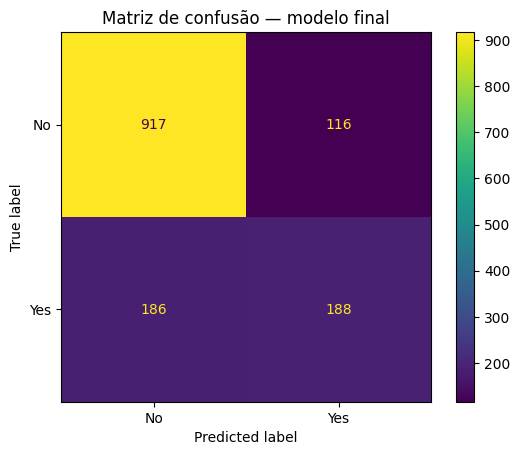

In [96]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações


Após a etapa de otimização de hiperparâmetros, o modelo Random Forest foi avaliado no conjunto de teste, composto por observações não utilizadas durante o treinamento nem durante o processo de seleção dos hiperparâmetros.

O modelo alcançou Accuracy de aproximadamente 79%, demonstrando boa capacidade geral de classificação. A análise das métricas por classe revelou desempenho superior na identificação dos clientes que permaneceram na empresa, com Recall de 89% para a classe "No".

Para a classe "Yes" (clientes que cancelaram os serviços), o modelo apresentou Precision de 62%, Recall de 50% e F1-Score de 55%. Esses resultados indicam que o modelo consegue identificar parte relevante dos clientes com risco de cancelamento, embora ainda existam oportunidades de melhoria na detecção dessa classe.

A matriz de confusão mostrou que 917 clientes foram corretamente classificados como não cancelados e 188 clientes foram corretamente identificados como cancelados. Por outro lado, ocorreram 186 falsos negativos, representando clientes que efetivamente cancelaram os serviços, mas não foram identificados pelo modelo.

Apesar dessa limitação, o desempenho obtido é significativamente superior ao modelo baseline, demonstrando que o algoritmo foi capaz de aprender padrões relevantes presentes nos dados e gerar previsões úteis para apoio à retenção de clientes.

**Do ponto de vista de negócio, essa limitação é relevante porque falsos negativos representam clientes com risco real de cancelamento que deixariam de ser priorizados por ações de retenção. Em contextos empresariais, pode ser desejável aumentar o recall da classe "Yes", mesmo com algum custo em precisão, caso o objetivo principal seja maximizar a identificação de clientes com risco de evasão.**

# 11. Comparação final dos modelos

| Modelo | Accuracy | F1-Score | ROC-AUC | Tempo de treino | Observações |
|---|---:|---:|---:|---:|---|
| Baseline | 0,734 | 0,622 | 0,500 | 0,073 s | Referência mínima, sem capacidade discriminatória |
| Logistic Regression | 0,804 | 0,800 | 0,836 | 0,100 s | Melhor desempenho inicial e melhor ROC-AUC |
| Random Forest | 0,787 | 0,778 | 0,814 | 0,947 s | Bom desempenho geral, porém inferior à Regressão Logística na avaliação inicial |
| Random Forest otimizado | 0,790 | 0,780 | — | RandomizedSearchCV | Modelo final avaliado após ajuste de hiperparâmetros |


**Observa-se que a Regressão Logística apresentou o melhor desempenho global na avaliação inicial, especialmente em termos de ROC-AUC. O Random Forest foi posteriormente otimizado com o objetivo de investigar possíveis ganhos de desempenho por meio de ajuste de hiperparâmetros, sendo utilizado como modelo final de avaliação.**

# 12. Boas práticas e rastreabilidade

Durante o desenvolvimento do projeto foram adotadas práticas voltadas à reprodutibilidade e rastreabilidade dos resultados.

O dataset foi disponibilizado através de um repositório GitHub público, permitindo acesso aos dados utilizados na construção do modelo. Todas as etapas de preparação, treinamento, validação e avaliação foram executadas dentro do notebook, possibilitando a reprodução integral dos experimentos.

Foi utilizada semente aleatória fixa (`random_state = 42`) para garantir consistência nos resultados obtidos durante a divisão dos dados e treinamento dos modelos.

Além disso, o pré-processamento foi encapsulado em pipelines do Scikit-Learn, reduzindo o risco de vazamento de dados e assegurando que as mesmas transformações sejam aplicadas de forma consistente em treinamento e teste.


**Registro de decisões:**

| Decisão                                                     | Justificativa                                                                           | Impacto esperado                                                                 |
| ----------------------------------------------------------- | --------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| Utilizar o dataset Telco Customer Churn                     | Dataset adequado para problemas de classificação e previsão de cancelamento de clientes | Permitir a construção de um modelo com aplicação prática em retenção de clientes |
| Remover a coluna `customerID`                               | Trata-se apenas de um identificador sem capacidade preditiva                            | Evitar ruído e possíveis problemas na modelagem                                  |
| Converter `TotalCharges` para formato numérico              | A variável foi carregada como texto devido à existência de registros vazios             | Permitir utilização correta da variável pelos algoritmos                         |
| Remover 11 registros com valores ausentes em `TotalCharges` | Registros inconsistentes identificados na análise exploratória                          | Melhorar a qualidade dos dados utilizados no treinamento                         |
| Utilizar divisão Holdout (80% treino / 20% teste)           | Estratégia amplamente utilizada em problemas de classificação                           | Avaliar o desempenho em dados não utilizados no treinamento                      |
| Aplicar One-Hot Encoding nas variáveis categóricas          | Os algoritmos exigem entradas numéricas                                                 | Permitir utilização de variáveis categóricas no modelo                           |
| Utilizar StandardScaler nas variáveis numéricas             | Padronizar escalas diferentes entre os atributos                                        | Melhorar o desempenho de algoritmos sensíveis à escala                           |
| Avaliar Regressão Logística e Random Forest                 | Comparar um modelo interpretável com um modelo mais robusto                             | Identificar a melhor abordagem para previsão de churn                            |
| Utilizar ROC-AUC como métrica principal                     | O dataset apresenta desbalanceamento moderado entre as classes                          | Avaliar adequadamente a capacidade discriminatória dos modelos                   |
| Realizar otimização de hiperparâmetros com RandomizedSearchCV | Buscar melhor configuração para o Random Forest com menor custo computacional | Melhorar a capacidade de generalização do modelo |



# 13. Conclusão


O presente projeto teve como objetivo desenvolver um modelo de Machine Learning capaz de prever o cancelamento de clientes utilizando o dataset Telco Customer Churn.

Durante a análise exploratória foram identificados fatores fortemente relacionados ao cancelamento, especialmente o tipo de contrato e o tempo de permanência dos clientes. Também foi identificado e tratado um problema de qualidade dos dados na variável `TotalCharges`, contribuindo para a melhoria da consistência da base utilizada.

Foram avaliados diferentes modelos de classificação, incluindo Regressão Logística e Random Forest, além de um modelo baseline utilizado como referência. Os resultados demonstraram que ambos os modelos superaram significativamente o baseline, confirmando a capacidade dos algoritmos de capturar padrões relevantes associados ao churn.

A Regressão Logística apresentou o melhor desempenho inicial entre os modelos avaliados, alcançando ROC-AUC de aproximadamente 0,836, além de melhor equilíbrio entre accuracy e F1-score. Posteriormente, foi realizada uma etapa de otimização de hiperparâmetros no Random Forest, com o objetivo de investigar possíveis ganhos adicionais de desempenho em um modelo mais flexível e sensível à calibração.

Após a otimização, o Random Forest ajustado foi utilizado como modelo final de avaliação no conjunto de teste, alcançando aproximadamente 79% de acurácia. Ainda assim, os resultados sugerem que, no contexto deste dataset, a Regressão Logística se destacou como a abordagem com melhor desempenho global, enquanto o Random Forest otimizado se mostrou uma alternativa válida para aprofundamento experimental.

Os resultados obtidos demonstram que técnicas de Machine Learning podem ser utilizadas com sucesso para apoiar estratégias de retenção de clientes, permitindo que empresas identifiquem clientes com maior probabilidade de cancelamento e adotem ações preventivas de relacionamento e fidelização.

Como trabalhos futuros, recomenda-se explorar algoritmos adicionais, como Gradient Boosting e XGBoost, bem como técnicas de balanceamento de classes para potencialmente aumentar a capacidade de detecção dos clientes com maior risco de churn.



# 14. Salvamento de artefatos

Não foi realizado salvamento de artefatos persistentes neste MVP, uma vez que o foco do projeto está na construção, avaliação e comparação dos modelos dentro do ambiente do notebook.


# 15. Apêndice opcional: Métodos avançados

Esta seção não foi aplicada neste projeto.

O problema de previsão de churn foi abordado utilizando algoritmos clássicos de Machine Learning, especificamente Regressão Logística e Random Forest, que apresentaram desempenho satisfatório para os objetivos propostos.

Considerando o tamanho do dataset e os resultados obtidos, não foi necessária a utilização de técnicas de Deep Learning, Fine-Tuning ou modelos avançados baseados em redes neurais.

Como possibilidade futura, poderiam ser avaliados algoritmos mais sofisticados, como Gradient Boosting, XGBoost ou arquiteturas de Deep Learning, visando investigar possíveis ganhos adicionais de desempenho.

